In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:/Users/mohda/Desktop/MacLrn/datasets/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.shape)
print(df.describe())

print(df.info())


(200, 5)
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500000               50.000000
75%    150.250000   49.000000           78.000000               73.000000
max    200.000000   70.000000          137.000000               99.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age     

In [4]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [5]:
## we dont need the customerID to be in our model
df.drop('CustomerID', axis=1, inplace=True)
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [6]:
df['Gender'] = df['Gender'].map({'Male':0,'Female':1})

In [7]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


## our data set is clear and clean 

### Standard sclaing 

z = (x − mean) / std

-3 to +3 approx


### MinMaxScaling 

x = (x - min) / (max - min)
0 to 1


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [9]:
scaled_data

array([[-1.12815215, -1.42456879, -1.73899919, -0.43480148],
       [-1.12815215, -1.28103541, -1.73899919,  1.19570407],
       [ 0.88640526, -1.3528021 , -1.70082976, -1.71591298],
       [ 0.88640526, -1.13750203, -1.70082976,  1.04041783],
       [ 0.88640526, -0.56336851, -1.66266033, -0.39597992],
       [ 0.88640526, -1.20926872, -1.66266033,  1.00159627],
       [ 0.88640526, -0.27630176, -1.62449091, -1.71591298],
       [ 0.88640526, -1.13750203, -1.62449091,  1.70038436],
       [-1.12815215,  1.80493225, -1.58632148, -1.83237767],
       [ 0.88640526, -0.6351352 , -1.58632148,  0.84631002],
       [-1.12815215,  2.02023231, -1.58632148, -1.4053405 ],
       [ 0.88640526, -0.27630176, -1.58632148,  1.89449216],
       [ 0.88640526,  1.37433211, -1.54815205, -1.36651894],
       [ 0.88640526, -1.06573534, -1.54815205,  1.04041783],
       [-1.12815215, -0.13276838, -1.54815205, -1.44416206],
       [-1.12815215, -1.20926872, -1.54815205,  1.11806095],
       [ 0.88640526, -0.

In [10]:
### make the dataframe of scaled_data
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)


In [11]:
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


- Raw data
-    ↓
- Encoding
-    ↓
- Scaling  ← (abhi kar rahe hain)
-    ↓
- Clustering
-    ↓
- Visualization


In [12]:
### all in one 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-1.128152,-1.424569,-1.738999,-0.434801
1,-1.128152,-1.281035,-1.738999,1.195704
2,0.886405,-1.352802,-1.700830,-1.715913
3,0.886405,-1.137502,-1.700830,1.040418
4,0.886405,-0.563369,-1.662660,-0.395980


- now to cluster the data we use algortim herte we will use KMeans

In [13]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters= 3,random_state=42)
clusters = kmeans.fit_predict(scaled_df)

In [14]:
clusters

array([2, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 0, 2,
       0, 0, 2, 2, 0, 0, 0, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 2,
       2, 0, 0, 2, 0, 0, 2, 2, 0, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 0,
       0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2,
       2, 2, 1, 2, 1, 2, 1, 2, 0, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1,
       1, 1], dtype=int32)

In [15]:
## add Cluster column to the df
scaled_df['Cluster'] = clusters
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,-1.128152,-1.424569,-1.738999,-0.434801,2
1,-1.128152,-1.281035,-1.738999,1.195704,2
2,0.886405,-1.352802,-1.700830,-1.715913,0
3,0.886405,-1.137502,-1.700830,1.040418,2
4,0.886405,-0.563369,-1.662660,-0.395980,0


### choosing maulayy the k is not the good approach now we need somet=hing can give us the right k value


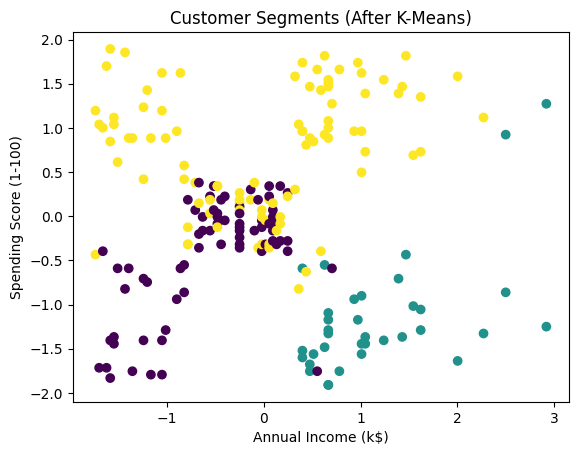

In [16]:
import matplotlib.pyplot as plt

plt.scatter(scaled_df['Annual Income (k$)'],scaled_df['Spending Score (1-100)'],c=scaled_df['Cluster'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (After K-Means)')
plt.show()

## Elbow Method

Inertia ka matlab:

Points apne cluster center se kitne door hain

In [17]:
from sklearn.cluster import KMeans 
import matplotlib.pyplot as plt

inertia = []

K_range = range(1,11)

for k in K_range:
    kmeans = KMeans(
        n_clusters = k,
        random_state=42
    )
    kmeans.fit(scaled_df.drop(['Cluster'],axis=1))
    inertia.append(kmeans.inertia_)

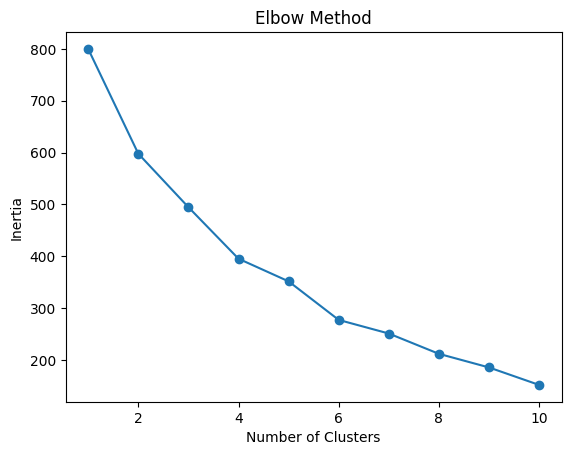

In [18]:
plt.plot(K_range,inertia,marker='o')

plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

thwe bend is the goof value of the cluster here it is k = 5

## now we will do the clustering with k = 5

In [19]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_df.drop('Cluster', axis=1))

scaled_df['Cluster'] = clusters



In [20]:
scaled_df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,-1.128152,-1.424569,-1.738999,-0.434801,2
1,-1.128152,-1.281035,-1.738999,1.195704,2
2,0.886405,-1.352802,-1.700830,-1.715913,4
3,0.886405,-1.137502,-1.700830,1.040418,4
4,0.886405,-0.563369,-1.662660,-0.395980,4


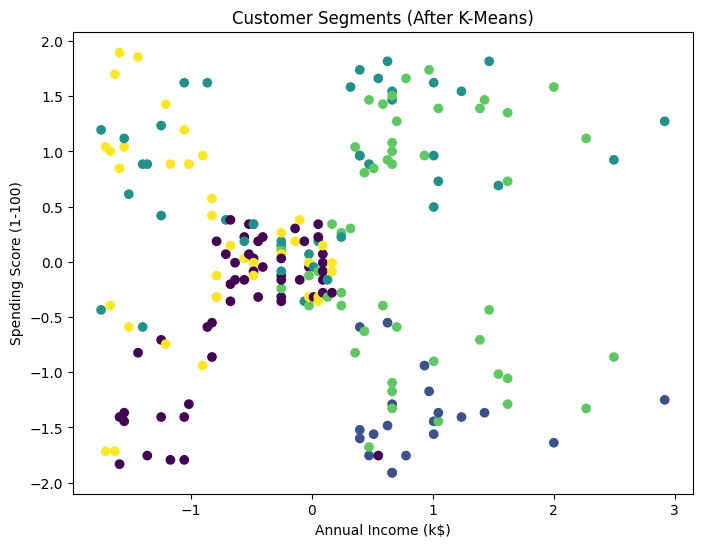

In [21]:
## visualize the data 
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df['Annual Income (k$)'],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (After K-Means)')
plt.show()

In [22]:
### average behaviour of clusters

centers = kmeans.cluster_centers_

centers_df = pd.DataFrame(centers, columns=df.columns)

centers_df


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,-0.140624,1.264571,-0.552005,-0.422622
1,-1.128152,0.046648,0.938586,-1.403399
2,-1.128152,-0.729115,0.013159,0.777910
3,0.886405,-0.068325,0.823026,0.164952
4,0.886405,-0.827772,-0.828960,0.233338


## Silhoutte Score 

this tells us wheather the cluster formed is good or not 

In [23]:
## range 
# 0.7 – 1.0  Excellent
# 0.5 – 0.7  Good
# 0.25 – 0.5 Average
# <0.25      Bad




from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df.drop('Cluster', axis=1), scaled_df['Cluster'])

print(f"Silhouette score: {score}")

Silhouette score: 0.27191023466188324


## our score is too bad to me interpretted our next step sould be to remove the gender column and check how it goes 

In [24]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [25]:
df.drop('Gender', axis=1, inplace=True)

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()


,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


In [27]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)

clusters = kmeans.fit_predict(scaled_df)

scaled_df['Cluster'] = clusters


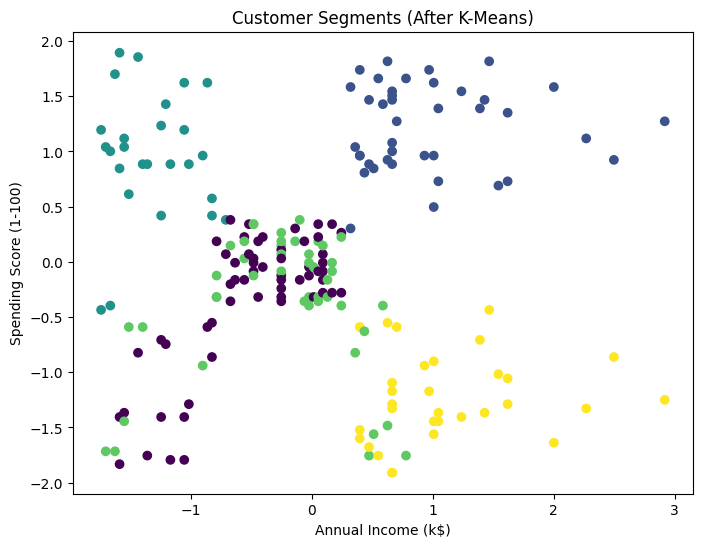

In [28]:
## visualize the data 
import matplotlib.pyplot as plt 

plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df['Annual Income (k$)'],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['Cluster']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (After K-Means)')
plt.show()

In [29]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df.drop('Cluster', axis=1), scaled_df['Cluster'])

print(score)


0.40846873777345605


# PCA  why? 

    This helps us to visulaized the higher dimentional features in 2D or 3D so that we can understand the data better

In [30]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components = 2
)

pca_data = pca.fit_transform(scaled_df.drop('Cluster', axis=1))

pca_df = pd.DataFrame(pca_data,columns=['PC1','PC2'])

pca_df['Cluster'] = scaled_df['Cluster']

pca_df.head()

,PC1,PC2,Cluster
0,-0.615720,-1.763481,2
1,-1.665793,-1.820747,2
2,0.337862,-1.674799,3
3,-1.456573,-1.772430,2
4,-0.038465,-1.662740,2


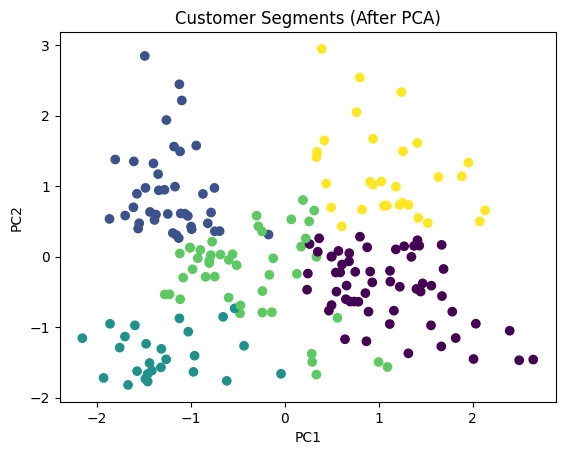

In [31]:
import matplotlib.pyplot as plt 

plt.scatter(pca_df['PC1'],pca_df['PC2'],c=pca_df['Cluster'])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segments (After PCA)')
plt.show()

In [32]:
## explained variane is the total info preserved 
print(pca.explained_variance_ratio_)


[0.44266167 0.33308378]


In [33]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance:", sum(pca.explained_variance_ratio_))


Explained variance ratio: [0.44266167 0.33308378]
Total variance: 0.7757454566976747


# Create the pipieline for the model 

In [34]:
from sklearn.pipeline import Pipeline 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

pipeline = Pipeline(steps=[
    ('scaler',StandardScaler()),
    ("pca",PCA(n_components=2)),
    ('kmeans',KMeans(
        n_clusters=5,
        random_state=42
    ))
])

pipeline.fit(df)

clusters = pipeline.predict(df)

df['Cluster'] = clusters

In [35]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,19,15,39,2
1,21,15,81,2
2,20,16,6,4
3,23,16,77,2
4,31,17,40,2


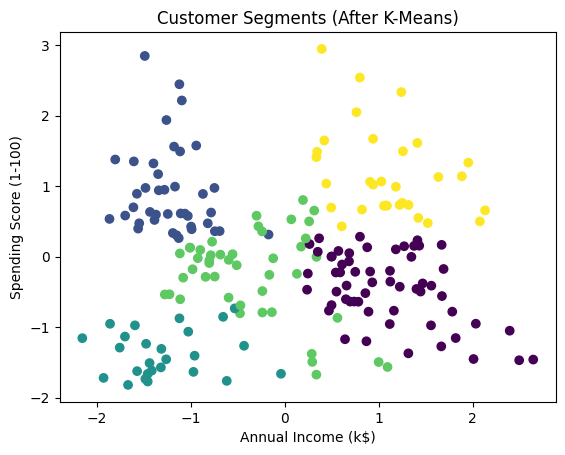

In [36]:
import matplotlib.pyplot as plt 

plt.scatter(pca_df['PC1'],pca_df['PC2'],c=pca_df['Cluster'])

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments (After K-Means)')
plt.show()

In [37]:
clusters[:10]

array([2, 2, 4, 2, 2, 2, 0, 2, 0, 2], dtype=int32)

----
=====================================================================

Dendrogram ek tree diagram hota hai jo dikhata hai:

kaunse customers pehle merge hue

kaunse baad mein merge hue

aur kitne natural clusters hain

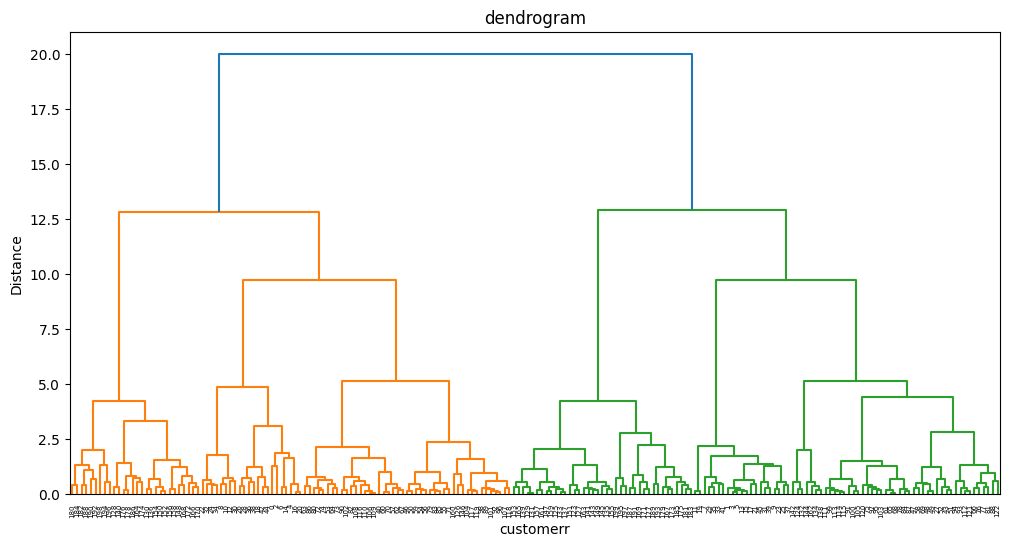

In [38]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt 

plt.figure(figsize=(12,6))

dendrogram = sch.dendrogram(
    sch.linkage(
        scaled_df.drop('Cluster',axis=1),
        method='ward'
    )
)

plt.title('dendrogram')
plt.xlabel('customerr')
plt.ylabel('Distance')

plt.show()

In [39]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5,
    metric='euclidean',
    linkage='ward'
)

hc_clusters = hc.fit_predict(scaled_df.drop('Cluster',axis=1))

scaled_df['HC_Cluster'] = hc_clusters

scaled_df.head()

,Age,Annual Income (k$),Spending Score (1-100),Cluster,HC_Cluster
0,-1.424569,-1.738999,-0.434801,2,4
1,-1.281035,-1.738999,1.195704,2,0
2,-1.352802,-1.700830,-1.715913,3,4
3,-1.137502,-1.700830,1.040418,2,0
4,-0.563369,-1.662660,-0.395980,2,4


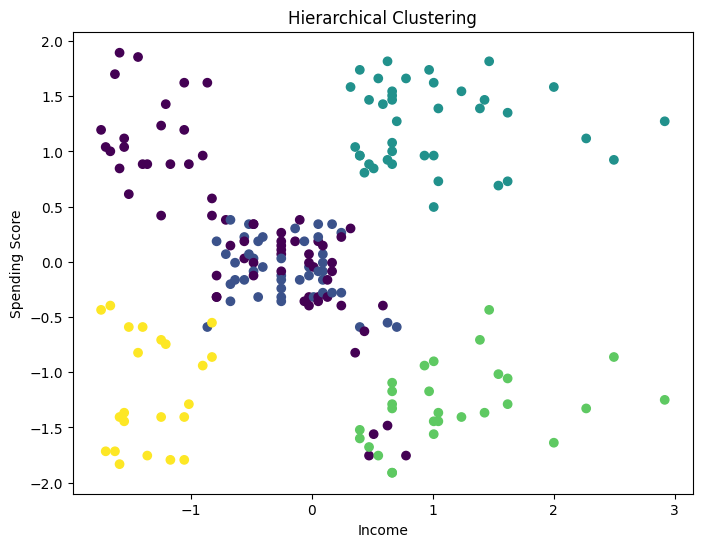

In [40]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df['Annual Income (k$)'],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['HC_Cluster']
)

plt.xlabel("Income")
plt.ylabel("Spending Score")

plt.title("Hierarchical Clustering")

plt.show()


In [41]:
from sklearn.metrics import silhouette_score

hc_score = silhouette_score(
    scaled_df.drop(['Cluster','HC_Cluster'], axis=1),
    scaled_df['HC_Cluster']
)

print("Hierarchical Silhouette Score:", hc_score)


Hierarchical Silhouette Score: 0.39002826186267214


## DBSCAN 

thi is usedv to detect the out liers from the data if any unusaual points existe ,
epi is the radius of its neibghor and nsmaple is the min points ot form as clustern 

In [42]:
from sklearn.cluster import DBSCAN 

dbscan = DBSCAN(
    eps=0.8,
    min_samples = 5
    )

db_clusters = dbscan.fit_predict(scaled_df.drop(['Cluster','HC_Cluster'],axis=1))

scaled_df["DBSCAN_Cluster"] = db_clusters

scaled_df['DBSCAN_Cluster'].value_counts()

DBSCAN_Cluster
 0    194
-1      6
Name: count, dtype: int64

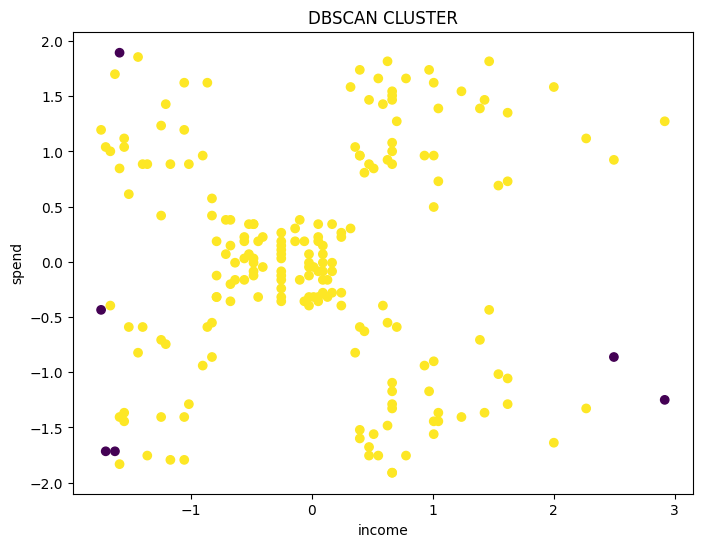

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_df["Annual Income (k$)"],
    scaled_df['Spending Score (1-100)'],
    c=scaled_df['DBSCAN_Cluster']
)

plt.xlabel('income')
plt.ylabel('spend')
plt.title('DBSCAN CLUSTER')
plt.show()

In [44]:
outliers = scaled_df[scaled_df['DBSCAN_Cluster'] == -1]

print("Number of outliers:", len(outliers))


Number of outliers: 6


## now we hve the outliers and we will remove it 

In [45]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

In [46]:
df_clean = df[~((df < lower) | (df > upper)).any(axis=1)]

In [47]:
print("Original shape:", df.shape)
print("New shape after removing outliers:", df_clean.shape)

Original shape: (200, 4)
New shape after removing outliers: (198, 4)


In [48]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(df_clean)

labels = kmeans.labels_


In [49]:
import numpy as np

unique, counts = np.unique(labels, return_counts=True)

print(dict(zip(unique, counts)))


{np.int32(0): np.int64(50), np.int32(1): np.int64(38), np.int32(2): np.int64(24), np.int32(3): np.int64(33), np.int32(4): np.int64(53)}


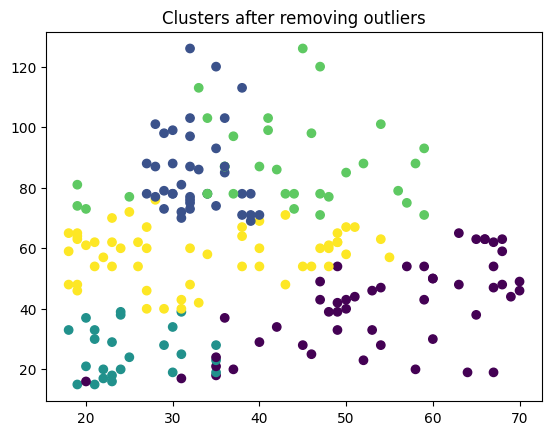

In [50]:
import matplotlib.pyplot as plt

plt.scatter(df_clean.iloc[:,0], df_clean.iloc[:,1], c=labels)
plt.title("Clusters after removing outliers")
plt.show()


## Gaussian Mixture Model (GMM)

K-Mean a point only belongs to one cluster

GMM a point is a% of cluster A and b% of cluster B

In [51]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=5,random_state=42)
gmm_label = gmm.fit_predict(df_clean)

gmm_label[:10]

array([2, 2, 4, 2, 2, 2, 0, 2, 0, 2])

In [52]:
from sklearn.metrics import silhouette_score

gmm_score = silhouette_score(df_clean, gmm_label)

print("GMM Silhouette Score:", gmm_score)


GMM Silhouette Score: 0.30069168715018235


In [53]:
## Cluster probability 
probs = gmm.predict_proba(df_clean)

print(probs[:7])


[[0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]]


In [54]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)

outliers = iso.fit_predict(df_clean)
outliers

array([ 1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1, -1, -1])

In [55]:
import numpy as np

print("Outliers:", np.sum(outliers == -1))
print("Normal:", np.sum(outliers == 1))


Outliers: 10
Normal: 188


In [56]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)

tsne_result = tsne.fit_transform(df_clean)


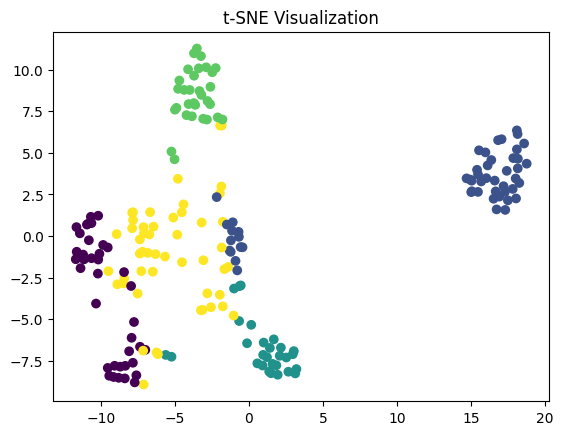

In [57]:
plt.scatter(tsne_result[:,0], tsne_result[:,1], c=gmm_label)
plt.title("t-SNE Visualization")
plt.show()


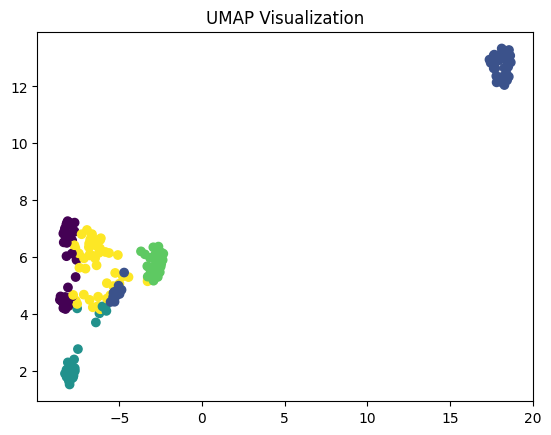

In [59]:
import umap

umap_model = umap.UMAP()

umap_result = umap_model.fit_transform(df_clean)

plt.scatter(umap_result[:,0], umap_result[:,1], c=gmm_label)
plt.title("UMAP Visualization")
plt.show()
